# Session 4 (Intro) - Reading charts with Seaborn

Before we build an interactive Streamlit app, let's learn to **read charts** on our steering wheel data.

Seaborn is a plotting library built on top of Matplotlib. It speaks *DataFrames* natively, so you point it at columns by name and it does the styling for you.

**The rhythm of this notebook:** question -> chart -> *what does it tell us?*

We reuse the Session 3 Parquet data via our shared `data_utils` helper - no copying, single source of truth.

In [1]:
# Imports. matplotlib gives us the canvas; seaborn draws pretty charts on it.
import matplotlib.pyplot as plt
import seaborn as sns

import data_utils as du  # our shared data layer (same folder)

# One line applies nice default styling to every chart below.
sns.set_theme(style="whitegrid")

# Load every station table into a dict: {"molding": df, "foaming": df, ...}
frames = du.load_all()

# Quick peek so we know what we are working with.
frames["molding"].head()

,product_id,batch_id,product_type,timestamp,shift,operator_id,mold_tool_id,temperature_c,humidity_pct,pressure_bar,mg_quantity_kg,duration_sec,cycle_result
0,PID000001,BATCH0001,PT77,2025-01-06 06:00:04,Morning,OP003,MT012,213.57,48.4,7.959,0.5069,58.2,OK
1,PID000002,BATCH0001,PT66,2025-01-06 06:04:26,Morning,OP009,MT005,205.59,51.9,10.151,0.5038,54.4,OK
2,PID000003,BATCH0001,PT77,2025-01-06 06:06:25,Morning,OP018,MT001,206.98,47.1,8.329,0.5349,40.8,OK
3,PID000004,BATCH0001,PT66,2025-01-06 06:10:25,Morning,OP013,MT010,187.63,50.3,8.007,0.4631,41.3,OK
4,PID000005,BATCH0001,PT55,2025-01-06 06:13:07,Morning,OP012,MT008,205.64,54.1,6.618,0.4542,67.6,OK


In [4]:
frames.keys()

dict_keys(['molding', 'quality_check', 'foaming', 'conductor', 'laser', 'tapitat'])

## 1. Bar chart - Which station scraps the most?

A **bar chart** compares a value across categories. Here: scrap rate (%) per station.

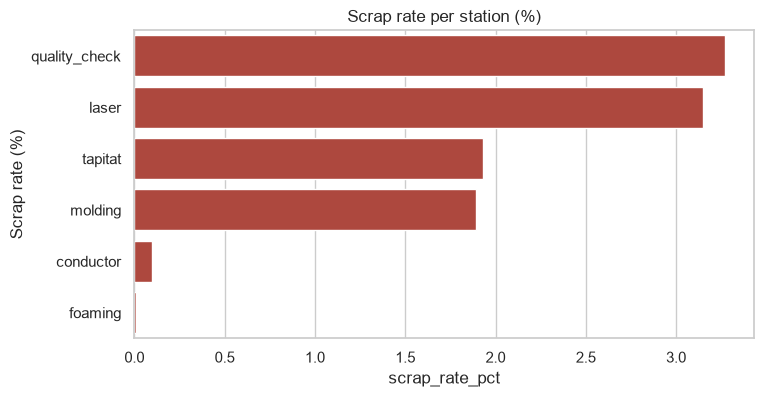

,station,scrap_rate_pct
1,quality_check,3.27
4,laser,3.15
5,tapitat,1.93
0,molding,1.89
3,conductor,0.10
2,foaming,0.01


In [6]:
# Our helper loops over every station and returns a tidy 2-column table.
station_scrap = du.scrap_rate_by_station(frames)

# fig = the canvas, ax = the area we draw on.
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=station_scrap, y="station", x="scrap_rate_pct", ax=ax, color="#c0392b")
ax.set_title("Scrap rate per station (%)")
ax.set_ylabel("Scrap rate (%)")
plt.show()

station_scrap

**Read it:** which station has the tallest bar? Is a high QC scrap rate a problem, or QC doing its job?

**Mini challenge:** flip to horizontal bars (swap `x` and `y`).

## 2. Line chart - Is quality drifting over time?

A **line chart** shows how a value changes across an ordered axis (time). Here: weekly scrap rate at molding.

In [ ]:
trend = du.weekly_scrap_trend(frames["molding"], "cycle_result")

fig, ax = plt.subplots(figsize=(10, 4))
sns.lineplot(data=trend, x="timestamp", y="scrap_rate_pct", marker="o", ax=ax)
ax.set_title("Weekly molding scrap rate (%)")
ax.set_ylabel("Scrap rate (%)")
ax.set_xlabel("Week")
plt.show()

**Read it:** is the line flat, rising, or spiky? A sudden spike is worth investigating (bad batch? tool wear?).

**Mini challenge:** change `weekly_scrap_trend` to resample by day (`"D"`) inside `data_utils` and compare.

## 3. Box plot - How does foam volume spread per product type?

A **box plot** shows the distribution: the box is the middle 50%, the line is the median, dots are outliers.

SIC targets: PT55 = 8 ml, PT66 = 10 ml, PT77 = 12 ml (+/- 0.5 ml tolerance).

In [ ]:
foaming = frames["foaming"]

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=foaming, x="product_type", y="foam_volume_ml", ax=ax)
ax.set_title("Foam volume distribution by product type")
ax.set_ylabel("Foam volume (ml)")
plt.show()

**Read it:** each type centres on its target. Are the outlier dots the ones that become UNDERFILL / OVERFILL / SCRAP?

**Mini challenge:** draw a horizontal target line per type with `ax.axhline(8.0, ...)`.

## 4. Heatmap - Which molding parameters move together?

A **correlation heatmap** shows how strongly numeric columns relate: +1 move together, -1 move opposite, 0 unrelated.

In [ ]:
molding = frames["molding"]
params = ["temperature_c", "pressure_bar", "humidity_pct", "mg_quantity_kg", "duration_sec"]

# .corr() computes the correlation matrix between the selected numeric columns.
corr = molding[params].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation of molding parameters")
plt.show()

**Read it:** most process parameters here are independent (near 0) because the data is well-controlled. In a real factory, a strong correlation (e.g. humidity vs a defect count) is a lead worth chasing.

---

## You're ready for Streamlit!

You now know four chart types and how to read them. Next, open the numbered scripts (`01_hello_streamlit.py` -> `05_dashboard.py`) and put these charts into a live, filterable dashboard.

**Final challenge:** pick ONE business question we haven't charted yet (e.g. conductor resistance vs the 2.5 ohm limit) and build the chart you think answers it best.